In [9]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [10]:
df = pl.read_parquet("flood_model_top30.parquet")

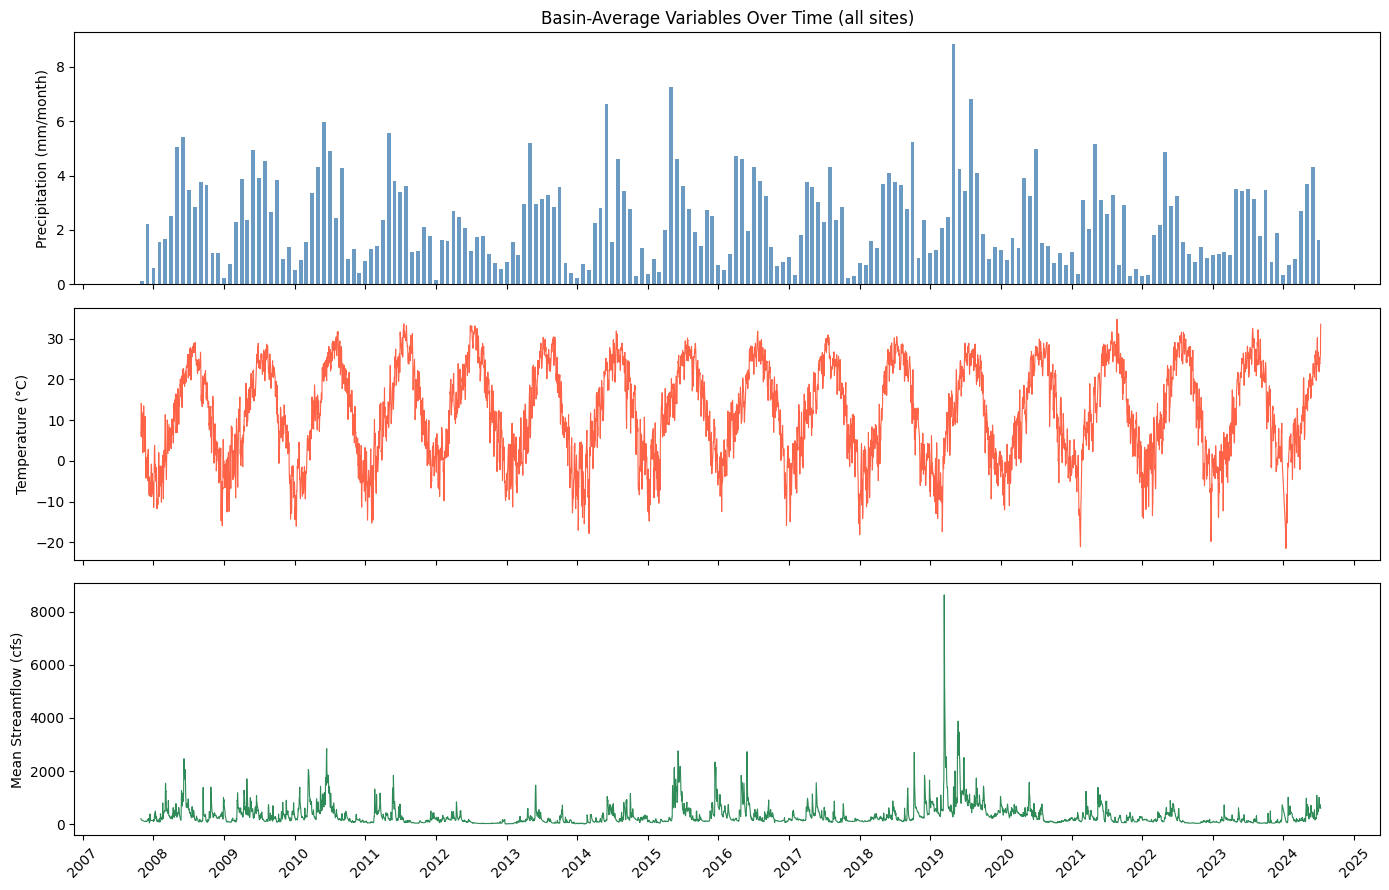

In [11]:
daily = (
    df.with_columns(pl.col("observation_hour").dt.truncate("1d").alias("date"))
    .group_by("date")
    .agg(
        pl.col("precipitation_mm").mean().alias("precip_daily_mean"),
        pl.col("temperature_c").mean(),
        pl.col("streamflow_cfs_mean").mean(),
    )
    .sort("date")
    .to_pandas()
)

# Monthly total precipitation (sum of daily basin-average precip)
monthly_precip = (
    daily.set_index("date")["precip_daily_mean"]
    .resample("MS")
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(monthly_precip["date"], monthly_precip["precip_daily_mean"], width=20, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Precipitation (mm/month)")
axes[0].set_title("Basin-Average Variables Over Time (all sites)")

axes[1].plot(daily["date"], daily["temperature_c"], color="tomato", linewidth=0.8)
axes[1].set_ylabel("Temperature (°C)")

axes[2].plot(daily["date"], daily["streamflow_cfs_mean"], color="seagreen", linewidth=0.8)
axes[2].set_ylabel("Mean Streamflow (cfs)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

## Gage Maps: Drainage Area and Snow Cover

Two maps of the top-30 dataset gages, colored by static watershed attributes.

> **Note:** `snow_ice_nlcd06` (NLCD permanent snow/ice) is 0 for all Missouri basin sites. `snw_pc_syr` (HydroATLAS annual snow cover %) captures seasonal snowpack variation and is used for the snow map instead.

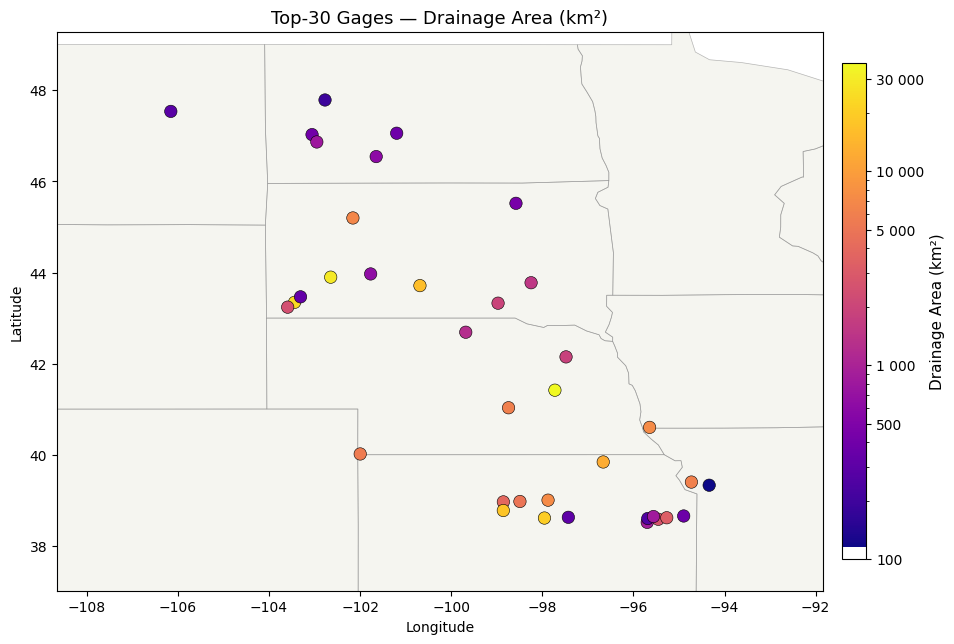

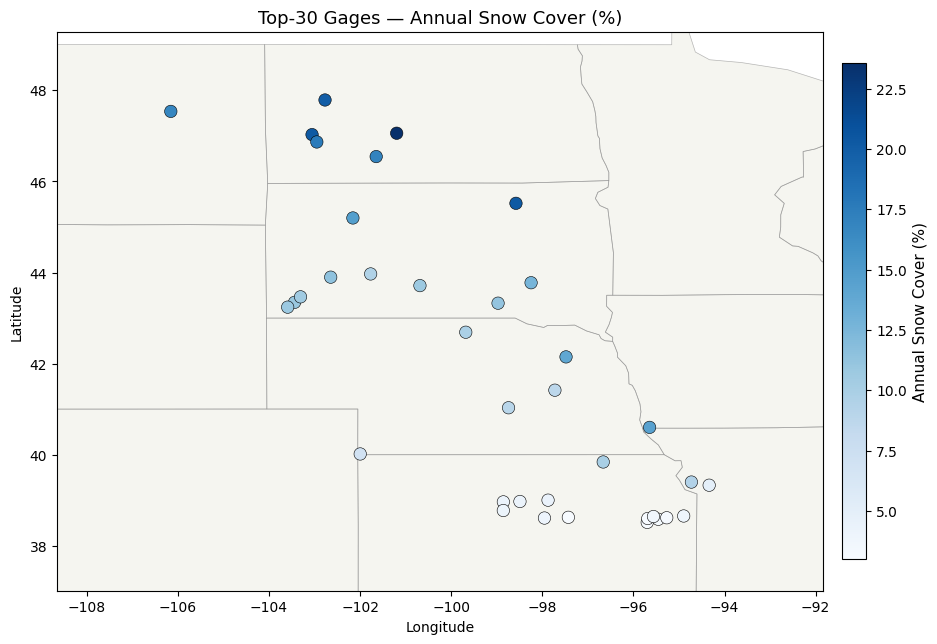

In [ ]:
import geopandas as gpd
from matplotlib.colors import LogNorm, Normalize

# One row per site with static attributes
sites = (
    df.select(["site_id", "station_name", "latitude", "longitude", "DRAIN_SQKM", "snw_pc_syr"])
    .unique(subset=["site_id"])
    .to_pandas()
)

# Load US state borders for geographic context (falls back gracefully if offline)
try:
    states = gpd.read_file(
        "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_1_states_provinces.geojson"
    )
    states = states[states["admin"] == "United States of America"]
    has_bg = True
except Exception:
    has_bg = False

pad_lon, pad_lat = 2.5, 1.5
lon_min = sites["longitude"].min() - pad_lon
lon_max = sites["longitude"].max() + pad_lon
lat_min = sites["latitude"].min() - pad_lat
lat_max = sites["latitude"].max() + pad_lat

maps = [
    ("DRAIN_SQKM", "Drainage Area (km²)", "plasma", True),
    ("snw_pc_syr",  "Annual Snow Cover (%)",    "Blues",  False),
]

for col, label, cmap, use_log in maps:
    fig, ax = plt.subplots(figsize=(10, 7))

    if has_bg:
        states.plot(ax=ax, color="#f5f5f0", edgecolor="none", zorder=0)
        states.boundary.plot(ax=ax, linewidth=0.5, color="#888888", alpha=0.6)

    vals = sites[col].values
    norm = LogNorm(vmin=vals.min(), vmax=vals.max()) if use_log else Normalize(vmin=vals.min(), vmax=vals.max())

    sc = ax.scatter(
        sites["longitude"], sites["latitude"],
        c=vals, cmap=cmap, norm=norm,
        s=80, edgecolors="black", linewidths=0.4, zorder=5,
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
    cb.set_label(label, fontsize=11)
    if use_log:
        cb.set_ticks([100, 500, 1000, 5000, 10000, 30000])
        cb.set_ticklabels(["100", "500", "1 000", "5 000", "10 000", "30 000"])

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Top-30 Gages — {label}", fontsize=13)
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()S